<a href="https://colab.research.google.com/github/vadhri/cfd-notebook/blob/main/differencing_schemes/quick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In order to increase the accuracy to higher oder, we need to explore to include more terms in interpolation.
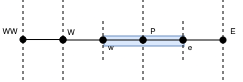

### QUICK Scheme (Derivation)

Assume interpolation at face:

$$
\phi_{i+1/2} = a\phi_{i+1} + b\phi_i + c\phi_{i-1}
$$

### Express nodes relative to face \( x_{i+1/2} \)

$$
\phi_{i+1} = \phi(x_{i+1/2} + h/2)
$$

$$
\phi_i = \phi(x_{i+1/2} - h/2)
$$

$$
\phi_{i-1} = \phi(x_{i+1/2} - 3h/2)
$$

### Taylor series expansions about \( x_{i+1/2} \)

$$
\phi(x_{i+1/2} \pm h/2)
= \phi_{i+1/2}
\pm \frac{h}{2}\phi'_{i+1/2}
+ \frac{1}{2!}\left(\frac{h}{2}\right)^2 \phi''_{i+1/2}
\pm \frac{1}{3!}\left(\frac{h}{2}\right)^3 \phi'''_{i+1/2}
+ \cdots
$$

$$
\phi(x_{i+1/2} - 3h/2)
= \phi_{i+1/2}
- \frac{3h}{2}\phi'_{i+1/2}
+ \frac{1}{2!}\left(\frac{3h}{2}\right)^2 \phi''_{i+1/2}
- \frac{1}{3!}\left(\frac{3h}{2}\right)^3 \phi'''_{i+1/2}
+ \cdots
$$

### Substitute into interpolation

$$
\phi_{i+1/2}
= a\phi_{i+1} + b\phi_i + c\phi_{i-1}
$$

$$
= a\phi(x_{i+1/2}+h/2)
+ b\phi(x_{i+1/2}-h/2)
+ c\phi(x_{i+1/2}-3h/2)
$$

### After substitution and grouping terms

$$
\phi_{i+1/2}
= (a+b+c)\phi_{i+1/2}
+ \frac{h}{2}(a - b - 3c)\phi'_{i+1/2}
+ \frac{h^2}{8}(a + b + 9c)\phi''_{i+1/2}
+ \frac{h^3}{48}(a - b - 27c)\phi'''_{i+1/2}
+ \cdots
$$

### For exact (higher-order) approximation

Match coefficients:

$$
a + b + c = 1
$$

$$
a - b - 3c = 0
$$

$$
a + b + 9c = 0
$$

### Solve system

$$
a = \frac{3}{8}, \quad b = \frac{6}{8}, \quad c = -\frac{1}{8}
$$

### Final QUICK interpolation

$$
\phi_{i+1/2}
= \frac{3}{8}\phi_{i+1}
+ \frac{6}{8}\phi_i
- \frac{1}{8}\phi_{i-1}
$$

### Convert QUICK generic interpretation to west and east faces

$$
\phi_w = \frac{6}{8}\phi_W + \frac{3}{8}\phi_P - \frac{1}{8}\phi_{WW}
$$

$$
\phi_e = \frac{6}{8}\phi_P + \frac{3}{8}\phi_E - \frac{1}{8}\phi_W
$$

Substitute into:

$$
F_e \phi_e - F_w \phi_w = D_e(\phi_E - \phi_P) - D_w(\phi_P - \phi_W)
$$

$$
F_e\left[\frac{6}{8}\phi_P + \frac{3}{8}\phi_E - \frac{1}{8}\phi_W\right]
- F_w\left[\frac{6}{8}\phi_W + \frac{3}{8}\phi_P - \frac{1}{8}\phi_{WW}\right]
$$

$$
= D_e(\phi_E - \phi_P) - D_w(\phi_P - \phi_W)
$$

Collect terms:

$$
\left(\frac{6}{8}F_e - \frac{3}{8}F_w + D_e + D_w\right)\phi_P
$$

$$
= \left(\frac{1}{8}F_e + \frac{6}{8}F_w + D_w\right)\phi_W
+ \left(D_e - \frac{3}{8}F_e\right)\phi_E
- \frac{1}{8}F_w \phi_{WW}
$$

Discretized form:

$$
a_P \phi_P = a_W \phi_W + a_E \phi_E + a_{WW}\phi_{WW}
$$

$$
a_W = D_w + \frac{6}{8}F_w + \frac{1}{8}F_e
$$

$$
a_E = D_e - \frac{3}{8}F_e
$$

$$
a_{WW} = -\frac{1}{8}F_w
$$

$$
a_P = a_W + a_E + a_{WW} + (F_e - F_w)
$$

The next step is to calculate node 1, node 2 and node 5 values after accomodating the missing values. The following calculations are taken from results of Table 5.10 from V&M book.

In [141]:
import numpy as np

def assemble_system(N, De, Dw, F, D_star_left, D_star_right, phi_A, phi_B):
    A = np.zeros((N, N))
    b = np.zeros(N)

    # -------------------------
    # Node 1 (boundary)
    # -------------------------
    i = 0

    a_WW = 0
    a_W  = 0
    a_E  = De + (1/3)*D_star_left - (3/8)*F

    S_P = -((8/3)*D_star_left + ((2/8)*F) + F)
    S_U = ((8/3)*D_star_left + ((2/8)*F)+F) * phi_A

    # print (f"node {i} = ", a_WW, a_W, a_E, S_U, S_P)

    A[i, i]   = (a_WW + a_W + a_E - S_P)
    A[i, i+1] = -a_E
    b[i] = S_U

    # -------------------------
    # Node 2 (special: has W but no WW)
    # -------------------------
    i = 1

    Fw = F
    Fe = F

    a_WW = 0
    a_W  = Dw + (7/8)*Fw + (1/8)*Fe
    a_E  = De - (3/8)*Fe

    S_P = (1/4)*Fw
    S_U = -(1/4)*Fw * phi_A

    A[i, i-1] = -a_W
    A[i, i]   = (a_WW + a_W + a_E - S_P)
    A[i, i+1] = -a_E
    b[i] = S_U

    # -------------------------
    # Interior nodes (i = 2 → N-3)
    # -------------------------
    for i in range(2, N-1):
        a_WW = -(1/8)*F
        a_W  = Dw + (6/8)*F + (1/8)*F
        a_E  = De - (3/8)*F

        S_P = 0
        S_U = 0

        # print (f"loop {i} a_WW={a_WW} a_W = {a_W} a_E = {a_E}")

        A[i, i-2] = -a_WW
        A[i, i-1] = -a_W
        A[i, i]   = (a_WW + a_W + a_E - S_P)
        A[i, i+1] = -a_E
        b[i] = S_U

    i += 1
    a_WW = -(1/8)*Fw
    a_W  = Dw + (1/3)*D_star_right + (6/8)*Fw
    a_E  = 0
    S_P = -((8/3)*D_star_right - Fw)
    S_U = ((8/3)*D_star_right - Fw) * phi_B

    A[i, i-2] = -a_WW
    A[i, i-1] = -a_W
    A[i, i]   = (a_WW + a_W + a_E - S_P)
    b[i] = S_U

    return A, b

In [136]:
# Function to calcuate pecklet number given u, rho, gamma and del x
rho = 1
u_velocity = 0.2
Gamma = 0.1
dx = 0.2
L = 1

F = rho*u_velocity
D = Gamma / dx

phi_a = 1
phi_b = 0

N = 5

A, b = assemble_system(
    N=5,
    De=D, Dw=D,
    F=F,
    D_star_left=D, D_star_right=D,
    phi_A=1, phi_B=0
)

print (np.round(A,3))

solution_quick = np.round(np.linalg.solve(A, b),4)

print(solution_quick)

[[ 2.175 -0.592  0.     0.     0.   ]
 [-0.7    1.075 -0.425  0.     0.   ]
 [ 0.025 -0.675  1.075 -0.425  0.   ]
 [ 0.     0.025 -0.675  1.075 -0.425]
 [ 0.     0.     0.025 -0.817  1.925]]
[0.9648 0.8707 0.7309 0.5226 0.2122]


In [139]:
def phi_analytical(x, phi_0, phi_L, rho, u, Gamma, L):
    numerator = np.exp(rho * u * x / Gamma) - 1
    denominator = np.exp(rho * u * L / Gamma) - 1
    return phi_0 + (phi_L - phi_0) * (numerator / denominator)

[0.96534656 0.8713239  0.73105858 0.5218073  0.20964108]


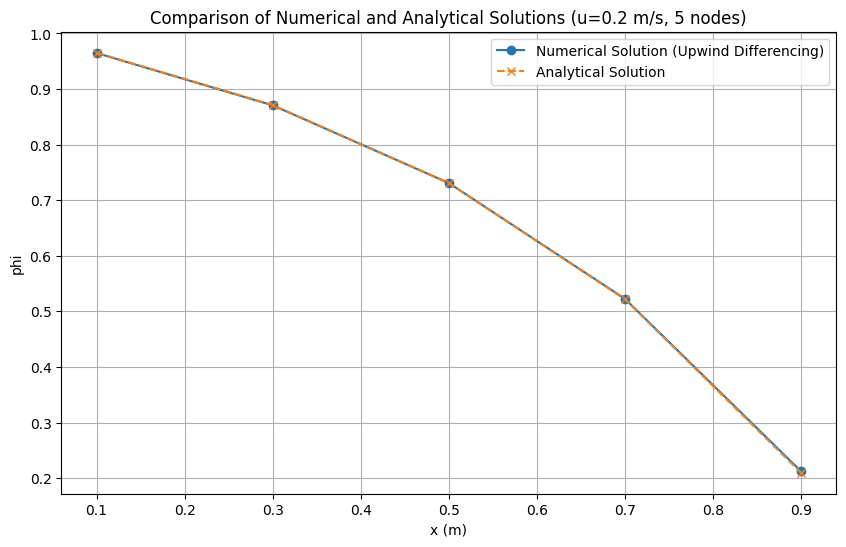

In [140]:

import matplotlib.pyplot as plt
num_nodes = N

# Calculate the effective grid spacing for plotting purposes
dx_effective = dx
# Generate x-coordinates for the numerical solution (nodes) as cell centers
x_numerical = np.linspace(dx_effective / 2, L - dx_effective / 2, num_nodes)

# Calculate analytical solution at the numerical node positions
phi_analytical_values = phi_analytical(x_numerical, phi_a, phi_b, rho, u_velocity, Gamma, L)
print (phi_analytical_values)
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_numerical, solution_quick, 'o-', label='Numerical Solution (Upwind Differencing)')
plt.plot(x_numerical, phi_analytical_values, 'x--', label='Analytical Solution')

plt.xlabel('x (m)')
plt.ylabel('phi')
plt.title(f'Comparison of Numerical and Analytical Solutions (u={u_velocity} m/s, {num_nodes} nodes)')
plt.grid(True)
plt.legend()
plt.show()
